# Least-Squares Reverse-Time Migration (LSRTM)

This notebook demonstrates LSRTM on a subregion of the Marmousi velocity model
at the original 4 m grid resolution, matching the exact setup from deepwave's
`example_lsrtm.py`.

## Problem Setup

| Parameter | Value |
|-----------|-------|
| Model | Marmousi subregion, 600 x 250, 4 m grid |
| Shots | 20, spacing 80 m, first at 40 m, depth 8 m |
| Receivers | 100, spacing 24 m, first at 0 m, depth 8 m |
| Frequency | 25 Hz Ricker |
| Time | 300 samples at 4 ms |
| FD accuracy | 8th order |
| Optimizer | L-BFGS, 3 iterations, loss x 1e6 |

## Theory

### The Acoustic Wave Equation (Forward Model)

Seismic wave propagation in a 2D acoustic medium with spatially varying
P-wave velocity $v(\mathbf{x})$ is governed by the scalar wave equation:

$$\frac{1}{v^2(\mathbf{x})} \frac{\partial^2 p}{\partial t^2} = \nabla^2 p + f(t)\,\delta(\mathbf{x} - \mathbf{x}_s)$$

where $p(\mathbf{x}, t)$ is the pressure wavefield, $f(t)$ is the source
time function (a Ricker wavelet), and $\mathbf{x}_s$ is the source position.
This equation is solved numerically using finite differences: 8th-order in
space and 2nd-order in time, with Convolutional Perfectly Matched Layer
(C-PML) absorbing boundary conditions on all sides.

### Born Approximation and the Scattering Potential

Now suppose the true velocity can be decomposed as a smooth background
$v_0(\mathbf{x})$ (the migration velocity) plus a perturbation:

$$\frac{1}{v^2(\mathbf{x})} = \frac{1}{v_0^2(\mathbf{x})}\bigl(1 + s(\mathbf{x})\bigr)$$

where $s(\mathbf{x})$ is the **scattering potential** (reflectivity). Under
the Born (single-scattering) approximation, the total wavefield is split
into a background field $p_0$ and a scattered field $\delta p$:

$$p = p_0 + \delta p$$

The background field satisfies the wave equation in $v_0$:

$$\frac{1}{v_0^2} \frac{\partial^2 p_0}{\partial t^2} = \nabla^2 p_0 + f(t)\,\delta(\mathbf{x} - \mathbf{x}_s)$$

Substituting the decomposition and linearizing (dropping $\delta p \cdot s$
terms), the scattered field satisfies:

$$\frac{1}{v_0^2} \frac{\partial^2 \delta p}{\partial t^2} = \nabla^2 \delta p + \underbrace{\frac{s(\mathbf{x})}{v_0^2} \frac{\partial^2 p_0}{\partial t^2}}_{\text{secondary source}}$$

This is the key insight: the scattering potential $s$ acts as a **secondary
source** that is driven by the background wavefield $p_0$. The scattered
field $\delta p$ propagates through the same background velocity $v_0$.
Crucially, this equation is **linear in $s$** — doubling $s$ doubles
$\delta p$.

### The Role of Migration Velocity

The migration velocity $v_\text{mig} = v_0$ serves two purposes:

1. **Direct arrival subtraction**: We forward-model through $v_\text{mig}$
   to compute the background data $d_0 = R\, p_0$ (where $R$ is the
   receiver sampling operator), then subtract from the observed data to
   isolate the scattered wavefield:
   $d^\text{scat} = d^\text{obs} - d_0$

2. **Born forward operator**: $v_\text{mig}$ defines the propagation
   paths for both the background wavefield (source-side) and the
   scattered wavefield (receiver-side). It determines *where* the
   reflected energy gets mapped in the subsurface — like a map that
   guides reflections back to their correct spatial positions.

In practice, $v_\text{mig}$ is obtained from prior velocity analysis
(e.g., tomography or FWI). Here, for benchmarking purposes, we construct
it by smoothing the true velocity's slowness field:
$v_\text{mig} = 1 \,/\, G_\sigma * (1/v_\text{true})$,
where $G_\sigma$ is a Gaussian filter with $\sigma = 5$ grid points (20 m).

### LSRTM Objective

Writing the Born forward operator compactly as $L$, the scattered data
at receivers is $d^\text{scat} = L\, s$. LSRTM solves:

$$\min_s \;\tfrac{1}{2}\sum_i \| L\, s - d_i^\text{scat} \|_2^2$$

Because $L$ is linear in $s$, this is a linear least-squares problem.
We solve it with the L-BFGS quasi-Newton optimizer, which converges
in very few iterations (typically 3–5).

### What Does the Output Mean?

The output $s(\mathbf{x})$ is the scattering potential — a reflectivity
image of the subsurface. It reveals **where velocity changes occur**
(layer boundaries, faults, lithology contrasts), not the absolute velocity
values. Positive $s$ indicates velocity increasing with depth; negative $s$
indicates decreasing velocity.

| | FWI | LSRTM |
|---|---|---|
| Output | Velocity $v(\mathbf{x})$ | Scattering potential $s(\mathbf{x})$ |
| Question answered | What is the wave speed at each point? | Where are the reflecting interfaces? |
| Analogy | CT scan (absolute density) | X-ray (density contrasts/edges) |
| Computation | Nonlinear, hundreds of iterations | Linear, 3–5 iterations |

In [1]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import numpy as np
import json
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load Precomputed Results

In [ ]:
ref_dir = 'evaluation/reference_outputs'
scatter = np.load(os.path.join(ref_dir, 'reference_reconstruction.npz'))['scatter'][0]
losses = np.load(os.path.join(ref_dir, 'losses.npz'))['losses']
pred_scattered = np.load(os.path.join(ref_dir, 'pred_scattered.npz'))['pred_scattered']
scattered_data = np.load(os.path.join(ref_dir, 'scattered_data.npz'))['scattered_data']

with open(os.path.join(ref_dir, 'metrics.json')) as f:
    metrics = json.load(f)

raw = np.load('data/raw_data.npz')
gt = np.load('data/ground_truth.npz')
v_true = gt['v_true'][0]
v_mig = raw['v_mig'][0]
observed_data = raw['observed_data'][0]
with open('data/meta_data.json') as f:
    meta = json.load(f)
dx = float(meta['preprocessing']['dx_m'])

ny, nx = v_true.shape
print(f'Model: {ny}x{nx} at {dx} m')
print(f'Data rel L2 (mean): {metrics["data_rel_l2_mean"]:.4f}')

## 2. Velocity Models

The true Marmousi velocity and the smooth migration velocity
$v_\text{mig} = 1 / G_\sigma * (1/v_\text{true})$ with $\sigma = 5$.
Note how $v_\text{mig}$ preserves the large-scale velocity trends but
removes the fine-scale reflectors that LSRTM will recover.

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_975725/1470889643.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('True Velocity $v(\mathbf{x})$'); axes[0].set_ylabel('Depth (m)')
/tmp/ipykernel_975725/1470889643.py:8: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('Migration Velocity $v_\mathrm{mig}$ (slowness smoothed, $\sigma=5$)')


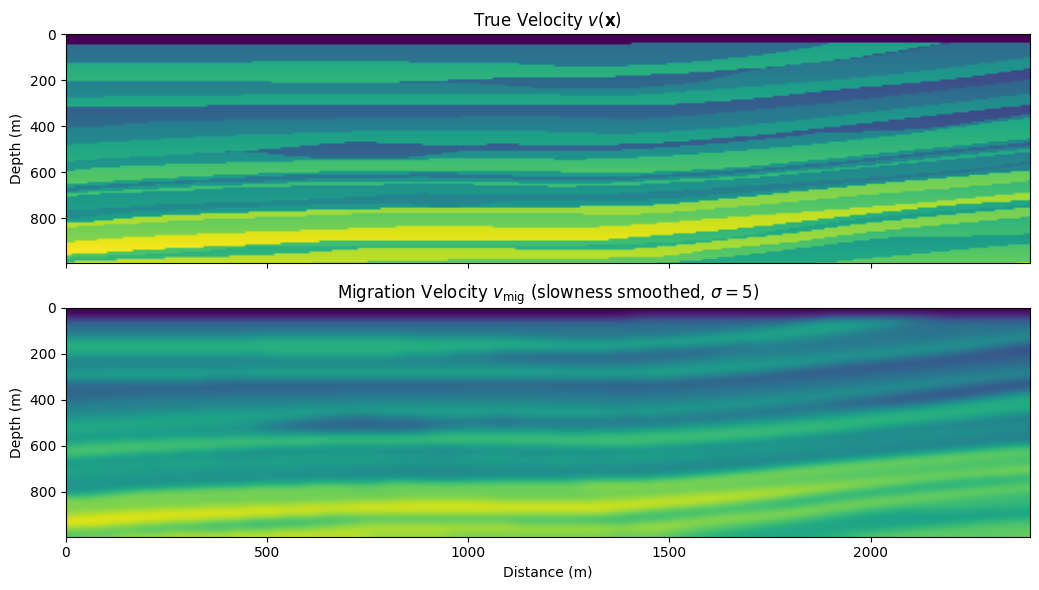

v_true range: [1500, 1960] m/s
v_mig  range: [1503, 1936] m/s
Relative difference: 0.0165 (1.65%)


In [3]:
extent = [0, (ny-1)*dx, (nx-1)*dx, 0]
vmin, vmax = v_true.min(), v_true.max()

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6), sharex=True)
axes[0].imshow(v_true.T, aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
axes[0].set_title('True Velocity $v(\mathbf{x})$'); axes[0].set_ylabel('Depth (m)')
axes[1].imshow(v_mig.T, aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
axes[1].set_title('Migration Velocity $v_\mathrm{mig}$ (slowness smoothed, $\sigma=5$)')
axes[1].set_xlabel('Distance (m)'); axes[1].set_ylabel('Depth (m)')
plt.tight_layout(); plt.show()

rel_diff = np.linalg.norm(v_true - v_mig) / np.linalg.norm(v_true)
print(f'v_true range: [{v_true.min():.0f}, {v_true.max():.0f}] m/s')
print(f'v_mig  range: [{v_mig.min():.0f}, {v_mig.max():.0f}] m/s')
print(f'Relative difference: {rel_diff:.4f} ({rel_diff*100:.2f}%)')

## 3. Direct Arrival Subtraction

We forward-model through $v_\text{mig}$ to compute the background data
$d_0 = R\, p_0$, then subtract from observed data to isolate the
scattered wavefield: $d^\text{scat} = d^\text{obs} - d_0$.

The left panel shows the full observed data (direct + scattered),
the middle panel shows the modeled direct arrivals, and the right panel
shows the isolated scattered (reflected) wavefield that LSRTM will invert.

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_975725/4085091049.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Observed $d^\mathrm{obs}$')
/tmp/ipykernel_975725/4085091049.py:8: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('Direct arrivals $d_0 = F(v_\mathrm{mig})$')
/tmp/ipykernel_975725/4085091049.py:10: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_title('Scattered $d^\mathrm{scat} = d^\mathrm{obs} - d_0$')


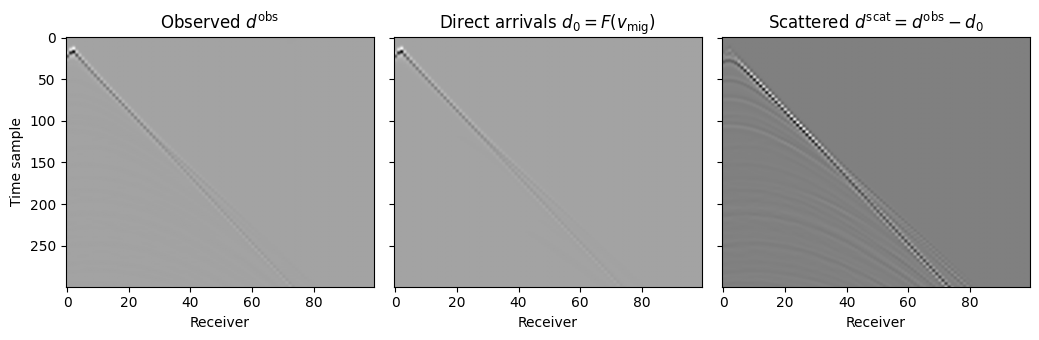

In [4]:
shot_idx = 0
direct = observed_data[shot_idx] - scattered_data[shot_idx]

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5), sharex=True, sharey=True)
axes[0].imshow(observed_data[shot_idx].T, aspect='auto', cmap='gray')
axes[0].set_title('Observed $d^\mathrm{obs}$')
axes[1].imshow(direct.T, aspect='auto', cmap='gray')
axes[1].set_title('Direct arrivals $d_0 = F(v_\mathrm{mig})$')
axes[2].imshow(scattered_data[shot_idx].T, aspect='auto', cmap='gray')
axes[2].set_title('Scattered $d^\mathrm{scat} = d^\mathrm{obs} - d_0$')
for ax in axes: ax.set_xlabel('Receiver')
axes[0].set_ylabel('Time sample')
plt.tight_layout(); plt.show()

## 4. LSRTM Image

The inverted scattering potential $s(\mathbf{x})$ after 3 L-BFGS
iterations. This is the reflectivity image: it shows where velocity
contrasts (layer boundaries, faults) exist in the subsurface, without
giving absolute velocity values.

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_975725/1524909906.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('LSRTM Image: Scattering Potential $s(\mathbf{x})$')


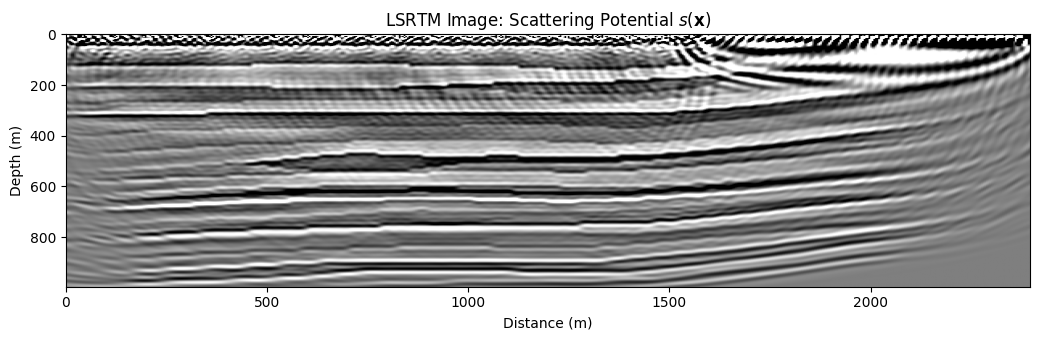

In [5]:
vmin_s, vmax_s = np.percentile(scatter, [5, 95])

fig, ax = plt.subplots(figsize=(10.5, 3.5))
ax.imshow(scatter.T, aspect='auto', cmap='gray', vmin=vmin_s, vmax=vmax_s, extent=extent)
ax.set_title('LSRTM Image: Scattering Potential $s(\mathbf{x})$')
ax.set_xlabel('Distance (m)'); ax.set_ylabel('Depth (m)')
plt.tight_layout(); plt.show()

## 5. Loss Convergence

L-BFGS converges rapidly because the Born operator is linear in $s$,
making this a linear least-squares problem.

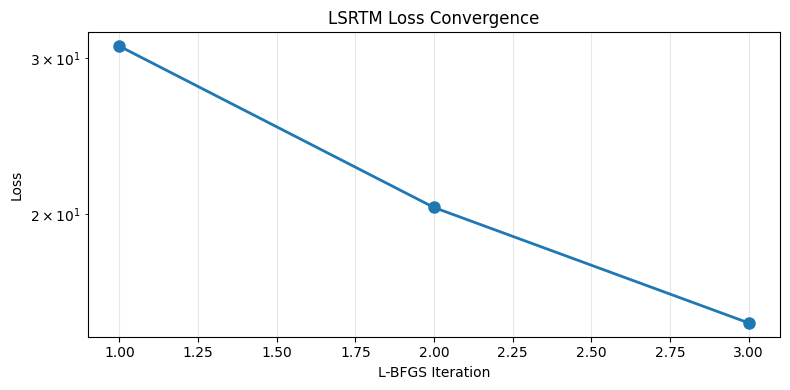

Loss: 3.10e+01 -> 1.51e+01 (2.1x reduction)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(losses)+1), losses, 'o-', linewidth=2, markersize=8)
ax.set_title('LSRTM Loss Convergence')
ax.set_xlabel('L-BFGS Iteration'); ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Loss: {losses[0]:.2e} -> {losses[-1]:.2e} ({losses[0]/losses[-1]:.1f}x reduction)')

## 6. Data Fit

Comparing the observed scattered data $d^\text{scat}$ with the
Born-predicted scattered data $L\,\hat{s}$ from the inverted
scattering potential.

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_975725/2454401640.py:8: SyntaxWarning: invalid escape sequence '\m'
  ['Observed $d^\mathrm{scat}$', 'Predicted $L\hat{s}$', 'Residual']):
/tmp/ipykernel_975725/2454401640.py:8: SyntaxWarning: invalid escape sequence '\h'
  ['Observed $d^\mathrm{scat}$', 'Predicted $L\hat{s}$', 'Residual']):


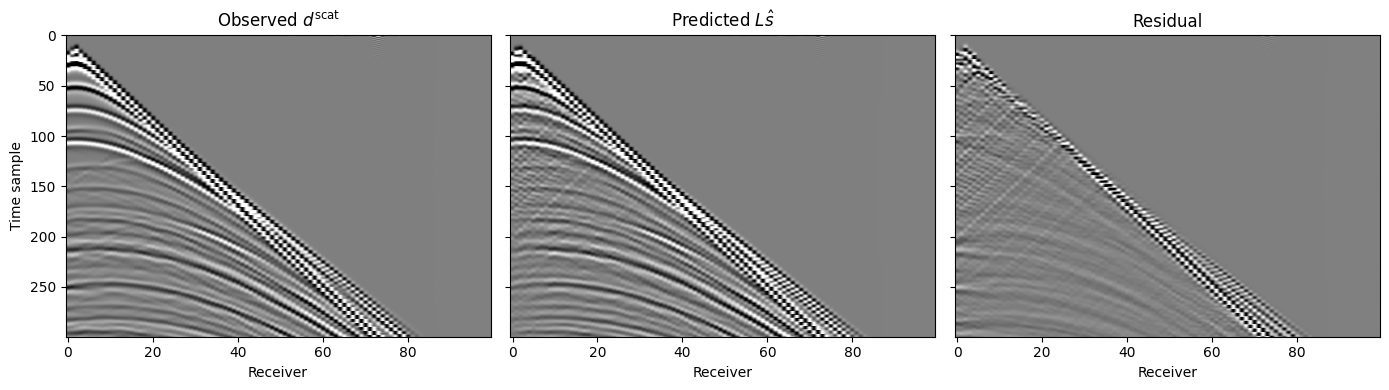

In [7]:
shot_idx = 0
amp = np.quantile(np.abs(scattered_data[shot_idx]), 0.95)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, d, t in zip(axes,
        [scattered_data[shot_idx], pred_scattered[shot_idx],
         pred_scattered[shot_idx] - scattered_data[shot_idx]],
        ['Observed $d^\mathrm{scat}$', 'Predicted $L\hat{s}$', 'Residual']):
    ax.imshow(d.T, cmap='gray', aspect='auto', vmin=-amp, vmax=amp)
    ax.set_title(t); ax.set_xlabel('Receiver')
axes[0].set_ylabel('Time sample')
plt.tight_layout(); plt.show()

## 7. Per-Shot Metrics

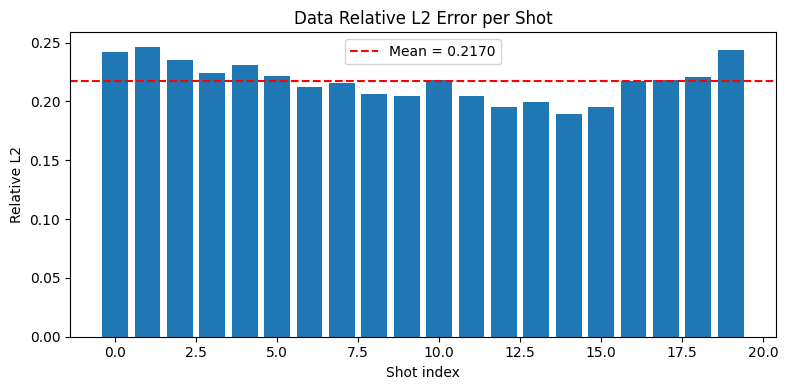

In [8]:
rel_l2 = metrics['data_rel_l2_per_shot']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(rel_l2)), rel_l2)
ax.axhline(metrics['data_rel_l2_mean'], color='r', linestyle='--',
           label=f'Mean = {metrics["data_rel_l2_mean"]:.4f}')
ax.set_title('Data Relative L2 Error per Shot')
ax.set_xlabel('Shot index'); ax.set_ylabel('Relative L2')
ax.legend()
plt.tight_layout(); plt.show()

## 8. Reproduce from Scratch (Optional)

Uncomment to run the full pipeline (~15 seconds on GPU).

In [9]:
# import torch
# from src.physics_model import make_acquisition_geometry, make_ricker_wavelet
# from src.solvers import subtract_direct_arrival, run_lsrtm
#
# device = torch.device('cuda')
# v_mig_t = torch.from_numpy(v_mig).to(device)
# obs_t = torch.from_numpy(observed_data).to(device)
# dt, freq = float(raw['dt']), float(raw['freq'])
#
# sl, rl = make_acquisition_geometry(device=device)
# w = make_ricker_wavelet(freq, 300, dt, 20, device)
#
# scat = subtract_direct_arrival(obs_t, v_mig_t, dx, dt, w, sl, rl, freq,
#     v_true_max=float(v_true.max()))
# scatter_inv, losses_new = run_lsrtm(v_mig_t, dx, dt, w, sl, rl, scat, freq,
#     n_epochs=3, device=device)
#
# vmin_s, vmax_s = np.percentile(scatter_inv.numpy(), [5, 95])
# plt.figure(figsize=(10.5, 3.5))
# plt.imshow(scatter_inv.numpy().T, aspect='auto', cmap='gray', vmin=vmin_s, vmax=vmax_s)
# plt.title('LSRTM Image (reproduced)'); plt.colorbar(); plt.show()

## Summary

This implementation matches deepwave's `example_lsrtm.py` exactly:
- 600x250 Marmousi subregion at 4 m grid
- 20 shots / 100 receivers with fixed spacing
- 25 Hz Ricker, 300 time samples
- 8th-order FD, L-BFGS 3 iterations

The LSRTM image shows clear reflector delineation across the Marmousi model
with only 3 L-BFGS iterations (~15 seconds on GPU).